# Testing the Effectiveness of a Campaign on Questionnaire Responsiveness

In [46]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, ttest_rel
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
# Upoad data
df = pd.read_csv("AdSmartABdata - AdSmartABdata.csv")

# Preliminary analysis

In [7]:
df.head()

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no
0,0008ef63-77a7-448b-bd1e-075f42c55e39,exposed,2020-07-10,8,Generic Smartphone,6,Chrome Mobile,0,0
1,000eabc5-17ce-4137-8efe-44734d914446,exposed,2020-07-07,10,Generic Smartphone,6,Chrome Mobile,0,0
2,0016d14a-ae18-4a02-a204-6ba53b52f2ed,exposed,2020-07-05,2,E5823,6,Chrome Mobile WebView,0,1
3,00187412-2932-4542-a8ef-3633901c98d9,control,2020-07-03,15,Samsung SM-A705FN,6,Facebook,0,0
4,001a7785-d3fe-4e11-a344-c8735acacc2c,control,2020-07-03,15,Generic Smartphone,6,Chrome Mobile,0,0


In [6]:
df.describe()

,hour,platform_os,yes,no
count,8077.000000,8077.000000,8077.000000,8077.000000
mean,11.615080,5.947134,0.070818,0.083075
std,5.734879,0.224333,0.256537,0.276013
min,0.000000,5.000000,0.000000,0.000000
25%,7.000000,6.000000,0.000000,0.000000
50%,13.000000,6.000000,0.000000,0.000000
75%,15.000000,6.000000,0.000000,0.000000
max,23.000000,7.000000,1.000000,1.000000


In [118]:
# Missing data
df[df.isnull().any(axis=1)]

,auction_id,experiment,date,hour,device_make,platform_os,browser,yes,no,dummy_experment,dummy_experiment


# Balanced data check

## Group sizes

In [39]:
df['experiment'].value_counts()

experiment
control    4071
exposed    4006
Name: count, dtype: int64

## Resposes over time

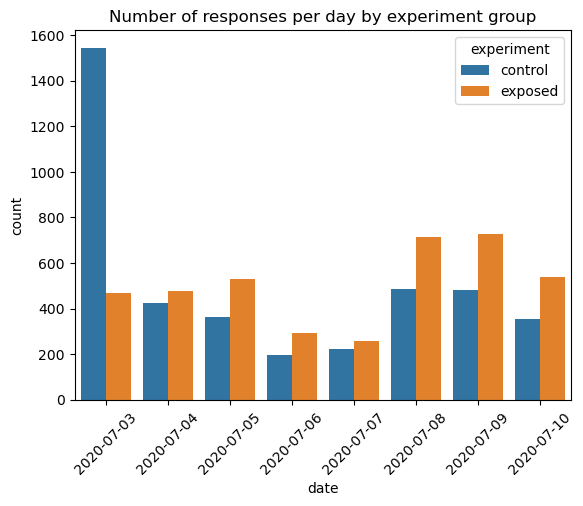

In [65]:
daily_counts = df.groupby(['date', 'experiment']).size().reset_index(name='count')
sns.barplot(daily_counts, x='date', y='count', hue = 'experiment')
plt.title("Number of responses per day by experiment group")
plt.xticks(rotation = 45)
plt.show()

## Browsers used across the groups

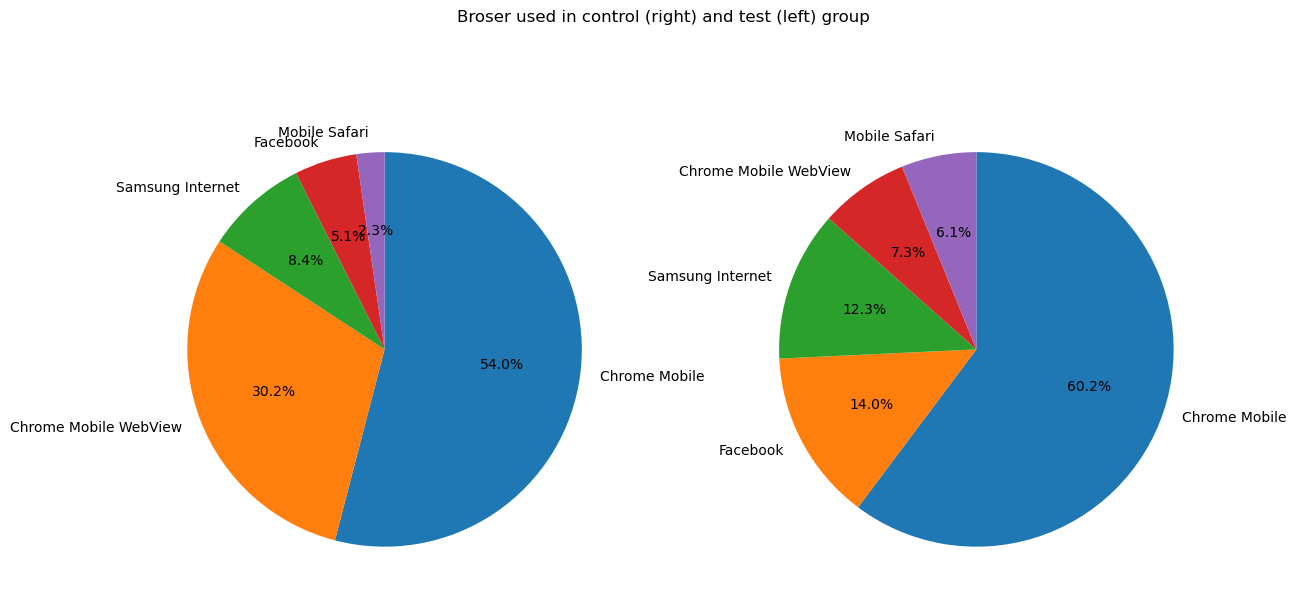

In [120]:
# Dummy Variable for 'experiment'
df['dummy_experiment'] = np.where(df['experiment'] == 'exposed', 1, 0)
# Control

exposed = df[df['dummy_experiment'] ==1].copy()
exposed_browser_types_c = exposed['browser'].value_counts().nlargest(5)
control = df[df['dummy_experiment'] ==0].copy()
colntrol_browser_types_c = control['browser'].value_counts().nlargest(5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,7))
fig.suptitle('Broser used in control (right) and test (left) group')
ax1.pie(exposed_browser_types_c,
        labels=exposed_browser_types_c.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False)
ax2.pie(colntrol_browser_types_c,
        labels=colntrol_browser_types_c.index,
        autopct='%1.1f%%',
        startangle=90,
        counterclock=False)
plt.show()

It is a well balanced dataset, as both groups have almost identical sample size.
The browsers used across the both groups are also roughly similar. One unbalanced day (2020-07-03) does not automatically invalidate your A/B test, but we should check why it’s unbalanced.

# Hypothesis
H0: mu_0 >= mu_1

H1: mu_0 < mu_1

This specifies one-sided alternative hypothesis, which tests that the mean number of 'yes' responses is greater in the exposed group than in the control group. The sample sizes are big, and populaiton standard deviartion is unknown, therefor t-statictic will be applied. We assume 95% confidence interval, which corresponds to 0.05 confidence level (allowable rate of false positives).

In [132]:
contorol_conversion = np.where((control['yes'] + control['no']) == 0, 0, control['yes'] / (control['yes'] + control['no']))

exposed_conversion = np.where((exposed['yes']+exposed['no'])==0,0,exposed['yes']/(exposed['yes']+exposed['no']))


In [139]:
from scipy import stats
t_stat, p_val = ttest_ind(contorol_conversion, exposed_conversion, alternative = 'greater')

In [140]:
print(f"P-value for the number of 'yes': {np.round(p_val,3)}")

P-value for the number of 'yes': 0.982


The lack of signifficant increase in the number of 'yes' selections suggests no substantial gain in the number of clients.